In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import erf, sqrt

CSV_PATH = "data.csv"

def parse_dt(s):
    s = s.astype(str).str.strip().replace({
        "": np.nan, " ": np.nan, "null": np.nan, "none": np.nan,
        "nan": np.nan, "nat": np.nan, "na": np.nan
    })
    return pd.to_datetime(s, utc=True, errors="coerce")

df = pd.read_csv(CSV_PATH, usecols=["user_id","order_id","status","created_at"])
df["status"] = df["status"].astype(str).str.strip().str.lower()
df["created_at"] = parse_dt(df["created_at"])
df = df.dropna(subset=["user_id","order_id","created_at"]).copy()

# 1 заказ = 1 строка
orders = (
    df.sort_values(["user_id","order_id","created_at"])
      .drop_duplicates(subset=["order_id"], keep="first")
      .copy()
)

orders["is_cancel"] = (orders["status"] == "cancelled").astype(int)

# Фичи пользователя
user_base = orders.groupby("user_id", as_index=False).agg(
    orders_count=("order_id","nunique"),
    cancel_count=("is_cancel","sum"),
    cancel_rate=("is_cancel","mean"),
    first_order_at=("created_at","min"),
    last_order_at=("created_at","max")
)
obs_end = orders["created_at"].max()
user_base["days_since_last"] = (obs_end - user_base["last_order_at"]).dt.days

# История интервалов между заказами
u = orders.sort_values(["user_id","created_at"]).copy()
u["prev_created_at"] = u.groupby("user_id")["created_at"].shift(1)
u["gap_days"] = (u["created_at"] - u["prev_created_at"]).dt.total_seconds()/86400
gap_stats = u.groupby("user_id", as_index=False).agg(
    avg_gap_days=("gap_days","mean"),
    med_gap_days=("gap_days","median")
)

user_df = user_base.merge(gap_stats, on="user_id", how="left")

# Churn-гипотезы на горизонтах
for h in [7, 14, 30]:
    user_df[f"churn_{h}d"] = (user_df["days_since_last"] >= h).astype(int)

print("Users:", len(user_df))
print(user_df[[f"churn_{h}d" for h in [7,14,30]]].mean().rename("rate"))
user_df.head()


Users: 78064
churn_7d     0.973342
churn_14d    0.952705
churn_30d    0.914929
Name: rate, dtype: float64


,user_id,orders_count,cancel_count,cancel_rate,first_order_at,last_order_at,days_since_last,avg_gap_days,med_gap_days,churn_7d,churn_14d,churn_30d
0,1,1,0,0.0,2024-10-14 10:31:40+00:00,2024-10-14 10:31:40+00:00,512,NaN,NaN,1,1,1
1,2,2,1,0.5,2020-06-24 23:00:38+00:00,2025-04-11 13:43:06+00:00,333,1751.612824,1751.612824,1,1,1
2,3,1,0,0.0,2022-09-05 21:23:16+00:00,2022-09-05 21:23:16+00:00,1282,NaN,NaN,1,1,1
3,4,1,0,0.0,2026-02-28 07:34:44+00:00,2026-02-28 07:34:44+00:00,10,NaN,NaN,1,0,0
4,6,1,1,1.0,2024-03-04 09:47:17+00:00,2024-03-04 09:47:17+00:00,736,NaN,NaN,1,1,1


Медианный интервал между заказами: 220.2 дн.
P75: 510.4 дн. | P90: 900.5 дн. | P95: 1164.4 дн.
Доля пользователей в зоне риска потери: 0.227


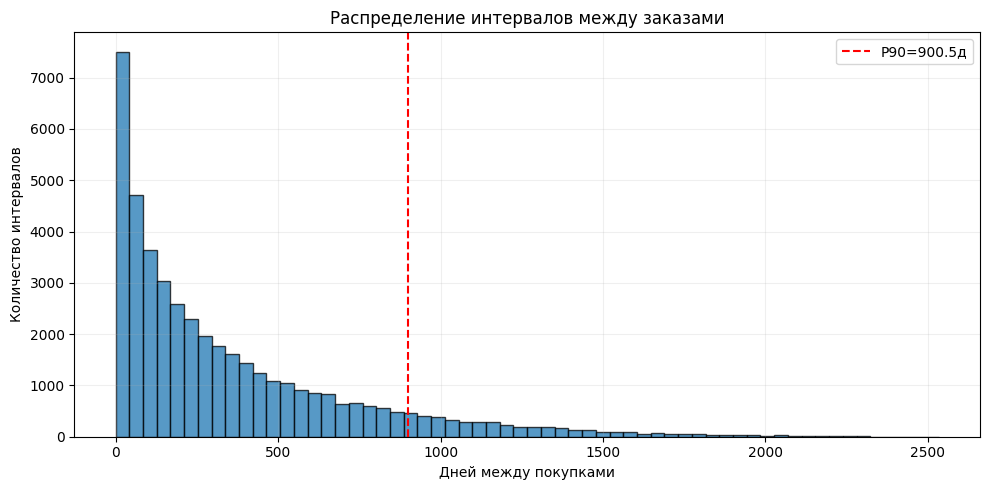

In [2]:
# Берем реальные интервалы у пользователей, которые возвращались
gaps = u["gap_days"].dropna()
gaps = gaps[gaps >= 0]

p50 = gaps.quantile(0.50)
p75 = gaps.quantile(0.75)
p90 = gaps.quantile(0.90)
p95 = gaps.quantile(0.95)

print(f"Медианный интервал между заказами: {p50:.1f} дн.")
print(f"P75: {p75:.1f} дн. | P90: {p90:.1f} дн. | P95: {p95:.1f} дн.")

# Практический критерий "теряем пользователя":
# если текущая неактивность > P90 исторических интервалов
user_df["risk_lost"] = (user_df["days_since_last"] > p90).astype(int)
print("Доля пользователей в зоне риска потери:", round(user_df["risk_lost"].mean(), 4))

plt.figure(figsize=(10,5))
plt.hist(gaps, bins=60, alpha=0.75, edgecolor="black")
plt.axvline(p90, color="red", linestyle="--", label=f"P90={p90:.1f}д")
plt.title("Распределение интервалов между заказами")
plt.xlabel("Дней между покупками")
plt.ylabel("Количество интервалов")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


,cancel_bin,churn_rate,users,avg_cancel_rate
0,"(-0.001, 0.25]",0.917342,62801,0.007106
1,"(0.25, 1.0]",0.904999,15263,0.742831


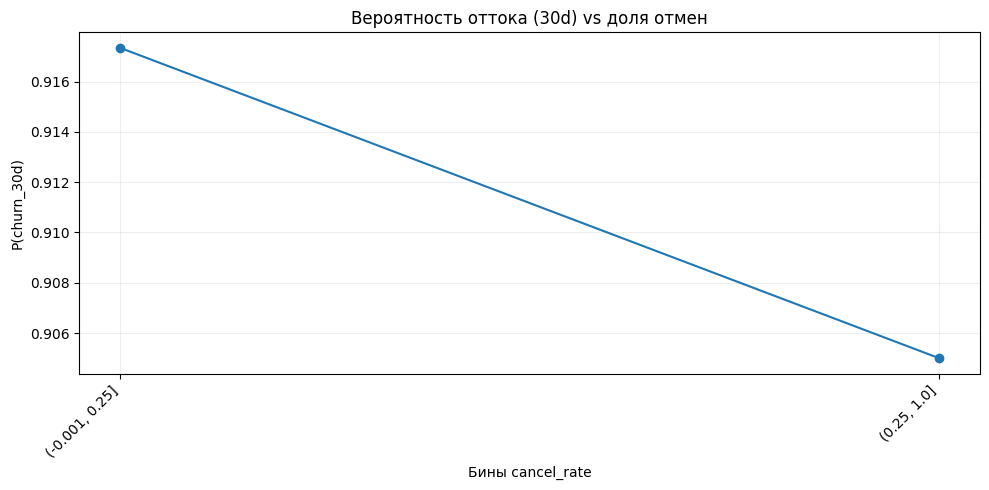

Churn rate (есть отмены): 0.8969 (n=17048)
Churn rate (нет отмен):  0.9200 (n=61016)
z=-9.524, p-value=0.000000


In [3]:
# Возьмем churn_30d как основной
y = "churn_30d"

# Сегменты по cancel_rate
user_df["cancel_bin"] = pd.qcut(user_df["cancel_rate"], q=min(5, user_df["cancel_rate"].nunique()), duplicates="drop")
cancel_impact = user_df.groupby("cancel_bin", observed=True, as_index=False).agg(
    churn_rate=(y, "mean"),
    users=("user_id","nunique"),
    avg_cancel_rate=("cancel_rate","mean")
)
display(cancel_impact)

plt.figure(figsize=(10,5))
plt.plot(cancel_impact["cancel_bin"].astype(str), cancel_impact["churn_rate"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.title("Вероятность оттока (30d) vs доля отмен")
plt.xlabel("Бины cancel_rate")
plt.ylabel("P(churn_30d)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# z-test разницы долей churn у пользователей с отменами и без
grp1 = user_df[user_df["cancel_count"] > 0][y]
grp0 = user_df[user_df["cancel_count"] == 0][y]

p1, n1 = grp1.mean(), len(grp1)
p0, n0 = grp0.mean(), len(grp0)
p_pool = (grp1.sum() + grp0.sum()) / (n1 + n0)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n0))
z = (p1 - p0) / se if se > 0 else np.nan
p_value = 2 * (1 - 0.5 * (1 + erf(abs(z)/sqrt(2)))) if pd.notna(z) else np.nan

print(f"Churn rate (есть отмены): {p1:.4f} (n={n1})")
print(f"Churn rate (нет отмен):  {p0:.4f} (n={n0})")
print(f"z={z:.3f}, p-value={p_value:.6f}")


In [4]:
# Ячейка: risk_score 0..100 для поиска пользователей под риск ухода

import pandas as pd
import numpy as np

CSV_PATH = "data.csv"

def parse_dt(s):
    s = s.astype(str).str.strip().replace({
        "": np.nan, " ": np.nan, "null": np.nan, "none": np.nan,
        "nan": np.nan, "nat": np.nan, "na": np.nan
    })
    return pd.to_datetime(s, utc=True, errors="coerce")

df = pd.read_csv(CSV_PATH, usecols=["user_id","order_id","status","created_at","delivered_at"])
df["status"] = df["status"].astype(str).str.strip().str.lower()
df["created_at"] = parse_dt(df["created_at"])
df["delivered_at"] = parse_dt(df["delivered_at"])
df = df.dropna(subset=["user_id","order_id","created_at"]).copy()

orders = (
    df.sort_values(["user_id","order_id","created_at"])
      .drop_duplicates(subset=["order_id"], keep="first")
      .copy()
)

orders["is_cancel"] = (orders["status"] == "cancelled").astype(int)

obs_end = orders["created_at"].max()
user_base = orders.groupby("user_id", as_index=False).agg(
    orders_count=("order_id","nunique"),
    first_order_at=("created_at","min"),
    last_order_at=("created_at","max"),
    cancel_rate=("is_cancel","mean"),
    cancel_count=("is_cancel","sum"),
)
user_base["days_since_last"] = (obs_end - user_base["last_order_at"]).dt.total_seconds() / 86400

u = orders.sort_values(["user_id","created_at"]).copy()
u["prev_created_at"] = u.groupby("user_id")["created_at"].shift(1)
u["gap_days"] = (u["created_at"] - u["prev_created_at"]).dt.total_seconds() / 86400
u = u[(u["gap_days"].notna()) & (u["gap_days"] >= 0)].copy()

gap_stats = u.groupby("user_id", as_index=False).agg(
    avg_gap_days=("gap_days","mean"),
    med_gap_days=("gap_days","median"),
    last_gap_days=("gap_days","last"),
    gaps_count=("gap_days","count"),
)

# slowdown_factor > 1 => интервалы растут
gap_stats["slowdown_factor"] = gap_stats["last_gap_days"] / gap_stats["med_gap_days"].replace(0, np.nan)
gap_stats["slowdown_factor"] = gap_stats["slowdown_factor"].replace([np.inf, -np.inf], np.nan).fillna(1.0)

d = orders.dropna(subset=["delivered_at"]).copy()
d["delivery_days"] = (d["delivered_at"] - d["created_at"]).dt.total_seconds() / 86400
d = d[(d["delivery_days"] >= 0) & (d["delivery_days"] <= 120)]
delivery = d.groupby("user_id", as_index=False).agg(avg_delivery_days=("delivery_days","mean"))

user_df = (
    user_base
    .merge(gap_stats, on="user_id", how="left")
    .merge(delivery, on="user_id", how="left")
)

def rank01(s):
    s = s.fillna(s.median() if s.notna().any() else 0)
    if s.nunique() <= 1:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return s.rank(pct=True)

user_df["r_recency"] = rank01(user_df["days_since_last"])                # чем дольше нет заказа, тем выше риск
user_df["r_cancel"] = rank01(user_df["cancel_rate"])                     # больше отмен -> выше риск
user_df["r_slowdown"] = rank01(user_df["slowdown_factor"])               # растут интервалы -> выше риск
user_df["r_delivery"] = rank01(user_df["avg_delivery_days"])             # дольше доставка -> выше риск

user_df["r_low_freq"] = 1 - rank01(user_df["orders_count"])

weights = {
    "r_recency": 0.35,
    "r_cancel": 0.20,
    "r_slowdown": 0.20,
    "r_delivery": 0.10,
    "r_low_freq": 0.15,
}
user_df["risk_score_0_100"] = 100 * sum(user_df[k] * w for k, w in weights.items())

# Сегменты риска
user_df["risk_segment"] = pd.qcut(
    user_df["risk_score_0_100"],
    q=[0, 0.5, 0.8, 0.95, 1.0],
    labels=["Low", "Medium", "High", "Critical"],
    duplicates="drop"
)

cols = [
    "user_id", "risk_score_0_100", "risk_segment",
    "days_since_last", "orders_count", "cancel_rate",
    "avg_gap_days", "last_gap_days", "slowdown_factor", "avg_delivery_days"
]
risk_users = user_df[cols].sort_values("risk_score_0_100", ascending=False).reset_index(drop=True)

display(risk_users.head(20))
print(risk_users["risk_segment"].value_counts(dropna=False))

risk_users.to_csv("users_risk_score.csv", index=False)
print("Сохранено: users_risk_score.csv")


,user_id,risk_score_0_100,risk_segment,days_since_last,orders_count,cancel_rate,avg_gap_days,last_gap_days,slowdown_factor,avg_delivery_days
0,841,74.293144,Critical,2597.740174,1,1.0,NaN,NaN,NaN,NaN
1,31902,74.292696,Critical,2590.938727,1,1.0,NaN,NaN,NaN,NaN
2,27541,74.290006,Critical,2574.960174,1,1.0,NaN,NaN,NaN,NaN
3,15116,74.287764,Critical,2552.406447,1,1.0,NaN,NaN,NaN,NaN
4,28119,74.287316,Critical,2552.059005,1,1.0,NaN,NaN,NaN,NaN
5,58490,74.284177,Critical,2535.538437,1,1.0,NaN,NaN,NaN,NaN
6,33474,74.282832,Critical,2532.755266,1,1.0,NaN,NaN,NaN,NaN
7,37094,74.277900,Critical,2523.092234,1,1.0,NaN,NaN,NaN,NaN
8,71408,74.273865,Critical,2510.596493,1,1.0,NaN,NaN,NaN,NaN
9,58640,74.268036,Critical,2495.439375,1,1.0,NaN,NaN,NaN,NaN


risk_segment
Low         39032
Medium      23419
High        11709
Critical     3904
Name: count, dtype: int64
Сохранено: users_risk_score.csv


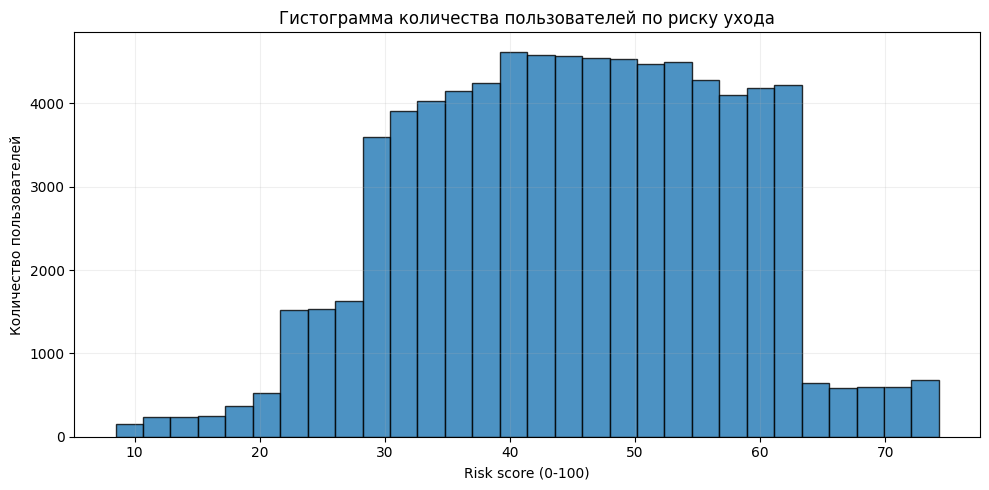

In [5]:
# Гистограмма количества пользователей по risk_score

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(risk_users["risk_score_0_100"], bins=30, edgecolor="black", alpha=0.8)
plt.title("Гистограмма количества пользователей по риску ухода")
plt.xlabel("Risk score (0-100)")
plt.ylabel("Количество пользователей")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


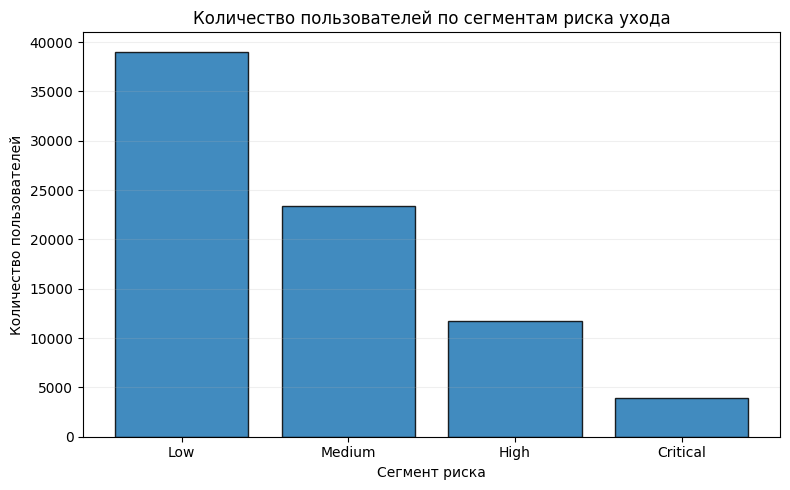

risk_segment
Low         39032
Medium      23419
High        11709
Critical     3904
Name: count, dtype: int64


In [6]:
# И дополнительно: столбчатая диаграмма по сегментам риска (Low/Medium/High/Critical)

seg_counts = risk_users["risk_segment"].value_counts().reindex(["Low", "Medium", "High", "Critical"]).fillna(0)

plt.figure(figsize=(8, 5))
plt.bar(seg_counts.index.astype(str), seg_counts.values, edgecolor="black", alpha=0.85)
plt.title("Количество пользователей по сегментам риска ухода")
plt.xlabel("Сегмент риска")
plt.ylabel("Количество пользователей")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

print(seg_counts)


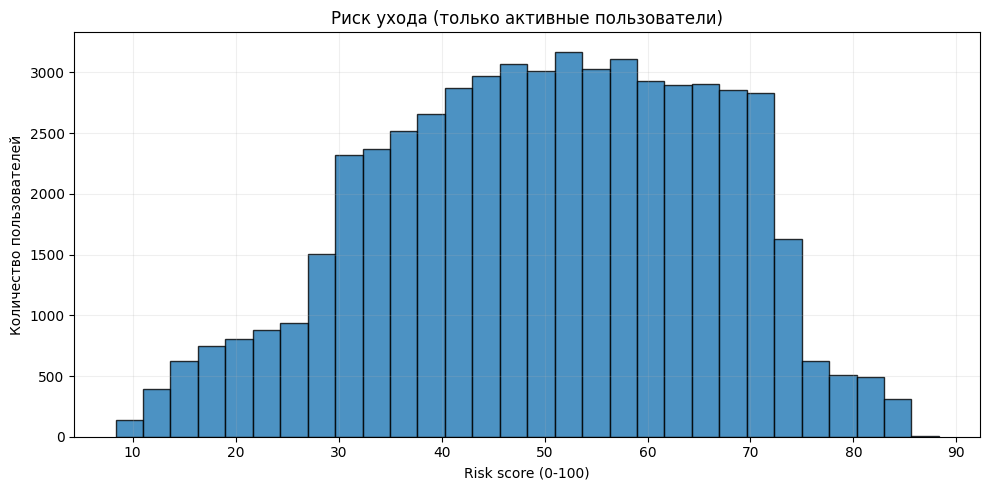

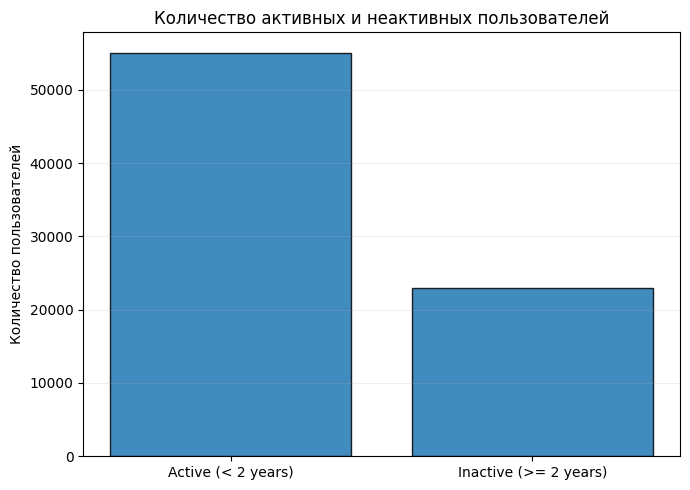

Всего пользователей: 78,064
Активные (< 2 лет без покупок): 55,099
Неактивные (>= 2 лет без покупок): 22,965
Сохранено: users_risk_with_inactive_2y.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "data.csv"
INACTIVE_DAYS = 365 * 2   # 2 года
# Весы risk score (для активных пользователей)
W_RECENCY = 0.45
W_CANCEL  = 0.20
W_GAP     = 0.20
W_FREQ    = 0.15


def parse_dt(s):
    s = s.astype(str).str.strip().replace({
        "": np.nan, " ": np.nan, "null": np.nan, "none": np.nan,
        "nan": np.nan, "nat": np.nan, "na": np.nan
    })
    return pd.to_datetime(s, utc=True, errors="coerce")

def rank01(s):
    s = s.copy()
    med = s.median() if s.notna().any() else 0
    s = s.fillna(med)
    if s.nunique() <= 1:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return s.rank(pct=True)

usecols = ["user_id", "order_id", "status", "created_at"]
df = pd.read_csv(CSV_PATH, usecols=usecols)

df["status"] = df["status"].astype(str).str.strip().str.lower()
df["created_at"] = parse_dt(df["created_at"])
df = df.dropna(subset=["user_id", "order_id", "created_at"]).copy()

orders = (
    df.sort_values(["user_id", "order_id", "created_at"])
      .drop_duplicates(subset=["order_id"], keep="first")
      .copy()
)
orders["is_cancel"] = (orders["status"] == "cancelled").astype(int)

obs_end = orders["created_at"].max()

user_base = orders.groupby("user_id", as_index=False).agg(
    orders_count=("order_id", "nunique"),
    cancel_rate=("is_cancel", "mean"),
    last_order_at=("created_at", "max"),
)

user_base["days_since_last"] = (obs_end - user_base["last_order_at"]).dt.total_seconds() / 86400

# Интервалы между покупками
u = orders.sort_values(["user_id", "created_at"]).copy()
u["prev_created_at"] = u.groupby("user_id")["created_at"].shift(1)
u["gap_days"] = (u["created_at"] - u["prev_created_at"]).dt.total_seconds() / 86400
u = u[(u["gap_days"].notna()) & (u["gap_days"] >= 0)].copy()

gap_stats = u.groupby("user_id", as_index=False).agg(
    avg_gap_days=("gap_days", "mean"),
    last_gap_days=("gap_days", "last"),
)

user_df = user_base.merge(gap_stats, on="user_id", how="left")

user_df["is_inactive_2y"] = (user_df["days_since_last"] >= INACTIVE_DAYS).astype(int)

active = user_df[user_df["is_inactive_2y"] == 0].copy()

active["r_recency"] = rank01(active["days_since_last"])
active["r_cancel"]  = rank01(active["cancel_rate"])
active["r_gap"]     = rank01(active["avg_gap_days"])
active["r_low_freq"] = 1 - rank01(active["orders_count"])

active["risk_score_0_100"] = 100 * (
    W_RECENCY * active["r_recency"] +
    W_CANCEL  * active["r_cancel"]  +
    W_GAP     * active["r_gap"]     +
    W_FREQ    * active["r_low_freq"]
)

user_df = user_df.merge(
    active[["user_id", "risk_score_0_100"]],
    on="user_id",
    how="left"
)

inactive_count = int(user_df["is_inactive_2y"].sum())
active_count = int((user_df["is_inactive_2y"] == 0).sum())

# 5.1 Гистограмма risk score только активных
plt.figure(figsize=(10, 5))
plt.hist(active["risk_score_0_100"], bins=30, edgecolor="black", alpha=0.8)
plt.title("Риск ухода (только активные пользователи)")
plt.xlabel("Risk score (0-100)")
plt.ylabel("Количество пользователей")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
labels = ["Active (< 2 years)", "Inactive (>= 2 years)"]
values = [active_count, inactive_count]
plt.bar(labels, values, edgecolor="black", alpha=0.85)
plt.title("Количество активных и неактивных пользователей")
plt.ylabel("Количество пользователей")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Всего пользователей: {len(user_df):,}")
print(f"Активные (< 2 лет без покупок): {active_count:,}")
print(f"Неактивные (>= 2 лет без покупок): {inactive_count:,}")

out = user_df[[
    "user_id", "orders_count", "cancel_rate",
    "days_since_last", "is_inactive_2y", "risk_score_0_100"
]].copy()

out.to_csv("users_risk_with_inactive_2y.csv", index=False)
print("Сохранено: users_risk_with_inactive_2y.csv")


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "data.csv"
CHURN_DAYS = 30  # можно поменять

def parse_dt(s):
    s = s.astype(str).str.strip().replace({
        "": np.nan, " ": np.nan, "null": np.nan, "none": np.nan,
        "nan": np.nan, "nat": np.nan, "na": np.nan
    })
    return pd.to_datetime(s, utc=True, errors="coerce")

usecols = ["user_id", "order_id", "status", "created_at", "delivered_at", "returned_at"]
df = pd.read_csv(CSV_PATH, usecols=[c for c in usecols if c in pd.read_csv(CSV_PATH, nrows=0).columns])

df["status"] = df["status"].astype(str).str.strip().str.lower()
df = df[df["status"].isin(["complete", "returned"])].copy()

df["created_at"] = parse_dt(df["created_at"])
df["delivered_at"] = parse_dt(df["delivered_at"])
if "returned_at" in df.columns:
    df["returned_at"] = parse_dt(df["returned_at"])

df = df.dropna(subset=["user_id", "order_id", "created_at"]).copy()

# 1 заказ = 1 строка
orders = (
    df.sort_values(["user_id", "order_id", "created_at"])
      .drop_duplicates(subset=["order_id"], keep="first")
      .copy()
)

orders["is_return"] = (orders["status"] == "returned").astype(int)
orders["delivery_days"] = (orders["delivered_at"] - orders["created_at"]).dt.total_seconds() / 86400
orders.loc[(orders["delivery_days"] < 0) | (orders["delivery_days"] > 120), "delivery_days"] = np.nan

print("orders:", len(orders), "users:", orders["user_id"].nunique())


orders: 1080 users: 895


       count      mean       std       min       25%       50%       75%  \
churn                                                                      
0      895.0  3.981938  1.733696  0.089583  2.649653  3.993056  5.252431   

           max  
churn           
0      7.73125  


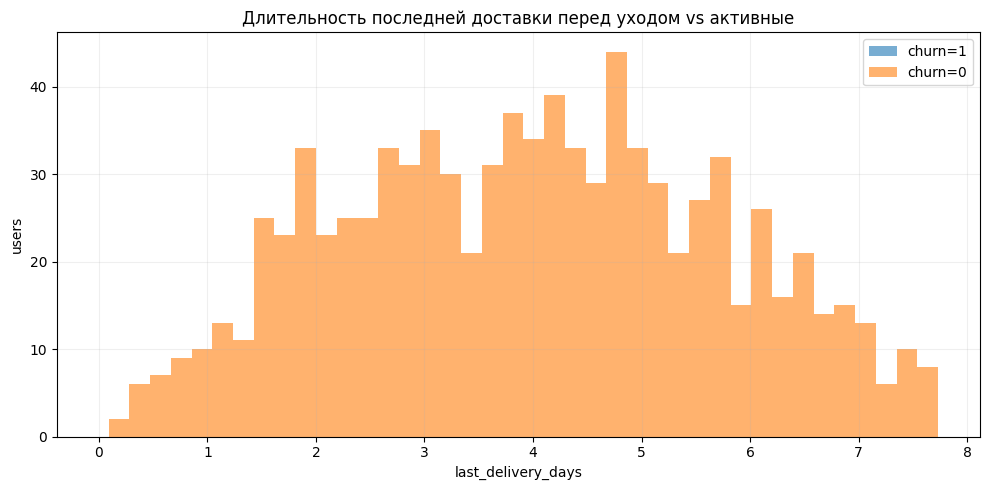

In [9]:
# churn по последней покупке
obs_end = orders["created_at"].max()

user_last = orders.groupby("user_id", as_index=False)["created_at"].max().rename(columns={"created_at": "last_order_at"})
user_last["days_since_last"] = (obs_end - user_last["last_order_at"]).dt.total_seconds() / 86400
user_last["churn"] = (user_last["days_since_last"] >= CHURN_DAYS).astype(int)

# последняя покупка пользователя (с её логистикой)
last_order = (
    orders.sort_values(["user_id", "created_at"])
          .groupby("user_id", as_index=False)
          .tail(1)
          .loc[:, ["user_id", "order_id", "status", "is_return", "delivery_days", "created_at"]]
          .rename(columns={"delivery_days": "last_delivery_days"})
)

last_user = user_last.merge(last_order, on="user_id", how="left")

print(last_user.groupby("churn")["last_delivery_days"].describe())

plt.figure(figsize=(10,5))
plt.hist(last_user.loc[last_user["churn"] == 1, "last_delivery_days"].dropna(), bins=40, alpha=0.6, label="churn=1")
plt.hist(last_user.loc[last_user["churn"] == 0, "last_delivery_days"].dropna(), bins=40, alpha=0.6, label="churn=0")
plt.title("Длительность последней доставки перед уходом vs активные")
plt.xlabel("last_delivery_days")
plt.ylabel("users")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


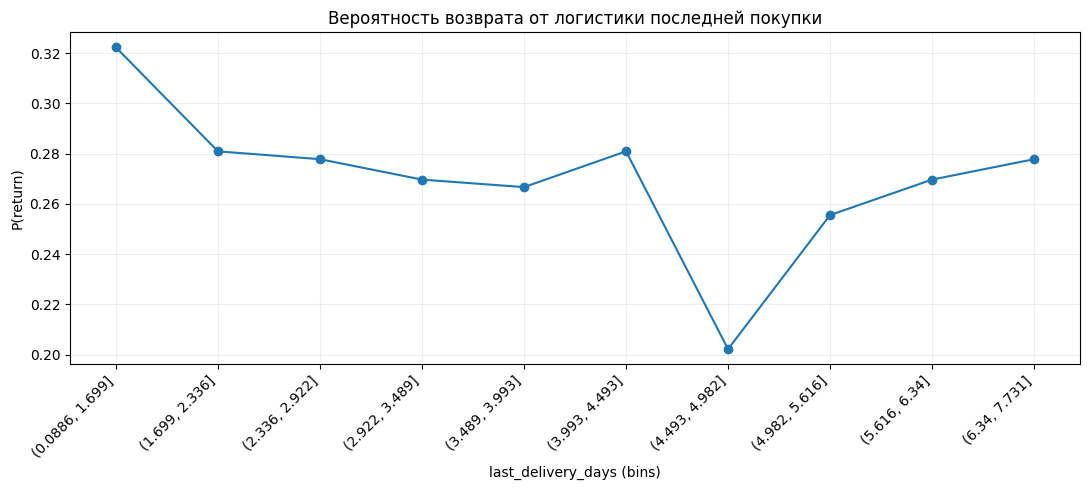

,delivery_bin,is_return
0,"(0.0886, 1.699]",0.322222
1,"(1.699, 2.336]",0.280899
2,"(2.336, 2.922]",0.277778
3,"(2.922, 3.489]",0.269663
4,"(3.489, 3.993]",0.266667
5,"(3.993, 4.493]",0.280899
6,"(4.493, 4.982]",0.202247
7,"(4.982, 5.616]",0.255556
8,"(5.616, 6.34]",0.269663
9,"(6.34, 7.731]",0.277778


In [10]:
tmp = last_user.dropna(subset=["last_delivery_days"]).copy()

q = min(10, tmp["last_delivery_days"].nunique())
if q >= 2:
    tmp["delivery_bin"] = pd.qcut(tmp["last_delivery_days"], q=q, duplicates="drop")
    ret_by_bin = tmp.groupby("delivery_bin", observed=True, as_index=False)["is_return"].mean()
    x = ret_by_bin["delivery_bin"].astype(str)
    y = ret_by_bin["is_return"]
else:
    ret_by_bin = tmp.groupby("last_delivery_days", as_index=False)["is_return"].mean().sort_values("last_delivery_days")
    x = ret_by_bin["last_delivery_days"].astype(str)
    y = ret_by_bin["is_return"]

plt.figure(figsize=(11,5))
plt.plot(x, y, marker="o")
plt.xticks(rotation=45, ha="right")
plt.title("Вероятность возврата от логистики последней покупки")
plt.xlabel("last_delivery_days (bins)")
plt.ylabel("P(return)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

display(ret_by_bin.head(15))


Общая частота возвратов: 0.273
count    895.000000
mean       0.274302
std        0.426168
min        0.000000
25%        0.000000
50%        0.000000
75%        0.500000
max        1.000000
Name: return_rate, dtype: float64


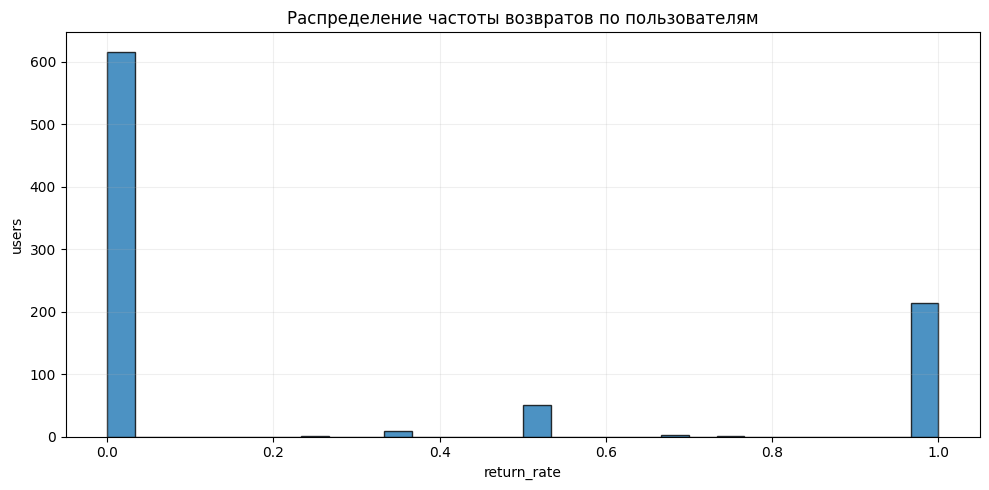

In [11]:
# общая частота возвратов
overall_return_rate = orders["is_return"].mean()
print(f"Общая частота возвратов: {overall_return_rate:.3f}")

# частота возвратов по пользователю
user_return = orders.groupby("user_id", as_index=False).agg(
    orders_count=("order_id", "nunique"),
    return_count=("is_return", "sum"),
    return_rate=("is_return", "mean")
)

print(user_return["return_rate"].describe())

plt.figure(figsize=(10,5))
plt.hist(user_return["return_rate"], bins=30, edgecolor="black", alpha=0.8)
plt.title("Распределение частоты возвратов по пользователям")
plt.xlabel("return_rate")
plt.ylabel("users")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression

# интервалы между заказами
u = orders.sort_values(["user_id", "created_at"]).copy()
u["prev_created_at"] = u.groupby("user_id")["created_at"].shift(1)
u["gap_days"] = (u["created_at"] - u["prev_created_at"]).dt.total_seconds() / 86400

gap_user = u.groupby("user_id", as_index=False).agg(
    avg_gap_days=("gap_days", "mean"),
    last_gap_days=("gap_days", "last")
)

delivery_user = orders.groupby("user_id", as_index=False).agg(
    avg_delivery_days=("delivery_days", "mean"),
    med_delivery_days=("delivery_days", "median")
)

user_feat = (
    user_last[["user_id", "churn", "days_since_last"]]
    .merge(user_return, on="user_id", how="left")
    .merge(gap_user, on="user_id", how="left")
    .merge(delivery_user, on="user_id", how="left")
    .merge(last_order[["user_id", "last_delivery_days", "is_return"]], on="user_id", how="left")
)

features = [
    "orders_count", "return_count", "return_rate",
    "avg_gap_days", "last_gap_days",
    "avg_delivery_days", "med_delivery_days", "last_delivery_days",
    "is_return"
]

X = user_feat[features].copy()
y = user_feat["churn"].copy()

X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=3000, class_weight="balanced")
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]
pred = model.predict(X_test)

print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
print(classification_report(y_test, pred, digits=4))

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": model.coef_[0],
    "odds_ratio": np.exp(model.coef_[0])
}).sort_values("coef", ascending=False)

display(coef_df)


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(0)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

CSV_PATH = "data.csv"
CHURN_DAYS = 30

def parse_dt(s):
    s = s.astype(str).str.strip().replace({
        "": np.nan, " ": np.nan, "null": np.nan, "none": np.nan,
        "nan": np.nan, "nat": np.nan, "na": np.nan
    })
    return pd.to_datetime(s, utc=True, errors="coerce")

df = pd.read_csv(CSV_PATH)

# ключевые даты
for c in ["created_at", "delivered_at", "returned_at", "sold_at"]:
    if c in df.columns:
        df[c] = parse_dt(df[c])

# статус
if "status" in df.columns:
    df["status"] = df["status"].astype(str).str.strip().str.lower()

# одна строка = один order_id
orders = (
    df.dropna(subset=["user_id", "order_id", "created_at"])
      .sort_values(["user_id", "order_id", "created_at"])
      .drop_duplicates(subset=["order_id"], keep="first")
      .copy()
)

orders["is_cancel"] = (orders["status"] == "cancelled").astype(int) if "status" in orders.columns else 0
orders["is_return"] = (orders["status"] == "returned").astype(int) if "status" in orders.columns else 0
orders["delivery_days"] = (orders["delivered_at"] - orders["created_at"]).dt.total_seconds()/86400
orders.loc[(orders["delivery_days"] < 0) | (orders["delivery_days"] > 120), "delivery_days"] = np.nan

print("orders:", len(orders), "users:", orders["user_id"].nunique())


/var/folders/4q/x5dr881s2zq0c00_zny4zsfc0000gn/T/ipykernel_90094/4054083297.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s = s.astype(str).str.strip().replace({


orders: 122048 users: 78064


In [14]:
obs_end = orders["created_at"].max()

# churn
last_purchase = orders.groupby("user_id", as_index=False)["created_at"].max().rename(columns={"created_at":"last_order_at"})
last_purchase["days_since_last"] = (obs_end - last_purchase["last_order_at"]).dt.days
last_purchase["churn"] = (last_purchase["days_since_last"] >= CHURN_DAYS).astype(int)

# интервалы между заказами
u = orders.sort_values(["user_id","created_at"]).copy()
u["prev_created_at"] = u.groupby("user_id")["created_at"].shift(1)
u["gap_days"] = (u["created_at"] - u["prev_created_at"]).dt.total_seconds()/86400
u.loc[u["gap_days"] < 0, "gap_days"] = np.nan

# user features
user_feat = orders.groupby("user_id", as_index=False).agg(
    orders_count=("order_id","nunique"),
    cancel_rate=("is_cancel","mean"),
    return_rate=("is_return","mean"),
    avg_delivery_days=("delivery_days","mean")
)

gap_feat = u.groupby("user_id", as_index=False).agg(
    avg_gap_days=("gap_days","mean"),
    median_gap_days=("gap_days","median")
)

user_df = (
    user_feat.merge(gap_feat, on="user_id", how="left")
             .merge(last_purchase[["user_id","days_since_last","churn"]], on="user_id", how="left")
)

# опц. демография/канал
for c in ["gender","age","traffic_source","is_loyal"]:
    if c in df.columns:
        mode_c = df.groupby("user_id")[c].agg(lambda x: x.dropna().mode().iloc[0] if len(x.dropna()) else np.nan).reset_index(name=c)
        user_df = user_df.merge(mode_c, on="user_id", how="left")

print("churn rate:", round(user_df["churn"].mean(), 4))
user_df.head()


churn rate: 0.9149


,user_id,orders_count,cancel_rate,return_rate,avg_delivery_days,avg_gap_days,median_gap_days,days_since_last,churn,gender,age,traffic_source,is_loyal
0,1,1,0.0,0.0,NaN,NaN,NaN,512,1,M,40,Search,False
1,2,2,0.5,0.0,NaN,1751.612824,1751.612824,333,1,F,46,Search,True
2,3,1,0.0,1.0,NaN,NaN,NaN,1282,1,F,51,Organic,False
3,4,1,0.0,0.0,NaN,NaN,NaN,10,0,F,26,Facebook,False
4,6,1,1.0,0.0,NaN,NaN,NaN,736,1,M,13,Search,False


In [16]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

cluster_cols = ["orders_count","cancel_rate","return_rate","avg_delivery_days","avg_gap_days","median_gap_days"]

Xc = user_df[cluster_cols].copy()

# 1) Приводим к числам
for c in cluster_cols:
    Xc[c] = pd.to_numeric(Xc[c], errors="coerce")

# 2) Убираем inf/-inf -> NaN
Xc = Xc.replace([np.inf, -np.inf], np.nan)

# 3) Удаляем полностью пустые колонки (иначе импайтер не поможет)
all_nan_cols = [c for c in Xc.columns if Xc[c].isna().all()]
if all_nan_cols:
    print("Удалены полностью пустые колонки:", all_nan_cols)
    Xc = Xc.drop(columns=all_nan_cols)

# 4) Импутация медианой
imp = SimpleImputer(strategy="median")
Xc_imp = imp.fit_transform(Xc)

# 5) На всякий случай финальная проверка
if np.isnan(Xc_imp).any():
    raise ValueError("После импутации всё ещё есть NaN. Проверь исходные признаки.")

# 6) Масштабирование
scaler = StandardScaler()
Xc_scaled = scaler.fit_transform(Xc_imp)

# 7) Подбор k
scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(Xc_scaled)
    scores[k] = silhouette_score(Xc_scaled, labels)

best_k = max(scores, key=scores.get)
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
user_df["cluster"] = kmeans.fit_predict(Xc_scaled)

print("best_k:", best_k, "silhouette:", round(scores[best_k], 4))
display(
    user_df.groupby("cluster")[["orders_count","cancel_rate","return_rate","avg_delivery_days","avg_gap_days","median_gap_days","churn"]]
          .mean()
          .round(3)
)


Удалены полностью пустые колонки: ['avg_delivery_days']


/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul


best_k: 7 silhouette: 0.701


,orders_count,cancel_rate,return_rate,avg_delivery_days,avg_gap_days,median_gap_days,churn
cluster,,,,,,,
0,2.109,0.151,0.104,NaN,120.897,120.897,0.836
1,1.041,0.000,0.000,NaN,356.565,356.565,0.938
2,3.678,0.152,0.097,NaN,252.143,219.518,0.854
3,2.020,0.141,0.100,NaN,1374.747,1374.747,0.935
4,2.270,0.148,0.104,NaN,670.519,672.132,0.939
5,1.044,1.000,0.000,NaN,238.220,238.220,0.932
6,1.034,0.000,1.000,NaN,265.932,264.971,0.935


Spearman(delivery,churn): nan
Pearson(delivery,churn): nan


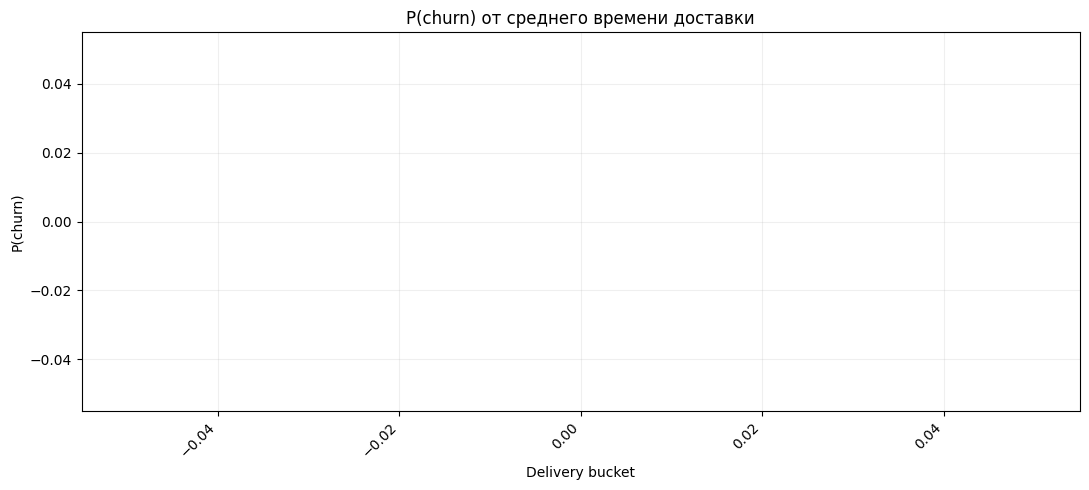

In [17]:
tmp = user_df.dropna(subset=["avg_delivery_days","churn"]).copy()

corr_s = tmp["avg_delivery_days"].corr(tmp["churn"], method="spearman")
corr_p = tmp["avg_delivery_days"].corr(tmp["churn"], method="pearson")
print("Spearman(delivery,churn):", round(corr_s, 4))
print("Pearson(delivery,churn):", round(corr_p, 4))

if tmp["avg_delivery_days"].nunique() >= 5:
    tmp["delivery_bin"] = pd.qcut(tmp["avg_delivery_days"], q=min(10, tmp["avg_delivery_days"].nunique()), duplicates="drop")
    plot_df = tmp.groupby("delivery_bin", observed=True, as_index=False)["churn"].mean()
    x = plot_df["delivery_bin"].astype(str)
    y = plot_df["churn"]
else:
    plot_df = tmp.groupby("avg_delivery_days", as_index=False)["churn"].mean().sort_values("avg_delivery_days")
    x = plot_df["avg_delivery_days"].astype(str)
    y = plot_df["churn"]

plt.figure(figsize=(11,5))
plt.plot(x, y, marker="o")
plt.xticks(rotation=45, ha="right")
plt.title("P(churn) от среднего времени доставки")
plt.xlabel("Delivery bucket")
plt.ylabel("P(churn)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [18]:
# fallback колонок
prod_col = "product_id" if "product_id" in df.columns else None
cat_col = "product_category" if "product_category" in df.columns else ("category" if "category" in df.columns else None)
dept_col = "product_department" if "product_department" in df.columns else ("department" if "department" in df.columns else None)
name_col = "product_name" if "product_name" in df.columns else None
review_col = "customer_review" if "customer_review" in df.columns else None

if prod_col is None:
    raise ValueError("Нет product_id для товарного анализа")

prod = df.dropna(subset=["user_id","order_id",prod_col,"created_at"]).copy()

# возврат по статусу
prod["status"] = prod["status"].astype(str).str.lower()
prod["is_return"] = (prod["status"] == "returned").astype(int)

# простая эвристика негативных review (если есть текст)
if review_col:
    txt = prod[review_col].fillna("").astype(str).str.lower()
    bad_words = ["bad","poor","broken","refund","return","late","disappoint","worse","problem"]
    prod["is_negative_review"] = txt.apply(lambda t: int(any(w in t for w in bad_words)))
else:
    prod["is_negative_review"] = 0

prod_quality = prod.groupby(prod_col, as_index=False).agg(
    buyers=("user_id","nunique"),
    orders=("order_id","nunique"),
    return_rate=("is_return","mean"),
    negative_review_rate=("is_negative_review","mean")
)

# метаданные
meta_cols = [c for c in [prod_col, name_col, cat_col, dept_col] if c is not None]
meta = prod[meta_cols].drop_duplicates(subset=[prod_col]).copy()
prod_quality = prod_quality.merge(meta, on=prod_col, how="left")

prod_quality["badness_score"] = 0.7*prod_quality["return_rate"] + 0.3*prod_quality["negative_review_rate"]
top_bad = prod_quality.sort_values("badness_score", ascending=False).head(20)

display(top_bad)


,product_id,buyers,orders,return_rate,negative_review_rate,product_name,product_category,product_department,badness_score
14019,14088,1,1,1.0,1.0,Eco-Friendly Premium Silky Soft Bamboo Fiber S...,Accessories,Women,1.0
706,708,2,2,1.0,1.0,Tapout Women's Performance Bra Top,Tops & Tees,Women,1.0
4122,4144,1,1,1.0,1.0,Allegra K Woman Elastic Waist Wide Leg Ruffle ...,Jumpsuits & Rompers,Women,1.0
2600,2613,1,1,1.0,1.0,Helly Hansen Women's Voss Pant,Active,Women,1.0
5901,5933,2,2,1.0,1.0,'Sexy Legs' Lovey-Dovey Black Leather Fashion ...,Leggings,Women,1.0
7386,7426,3,3,1.0,1.0,Karen Kane Women's Scallop Lace Pencil Skirt,Skirts,Women,1.0
9576,9630,1,1,1.0,1.0,Women's Warm Footie Pajama (Junior Sizes) - An...,Sleep & Lounge,Women,1.0
15133,15208,1,1,1.0,1.0,Paige Maternity Jeans : Union Laurel Canyon - ...,Maternity,Women,1.0
4981,5007,1,1,1.0,1.0,7 For All Mankind Women's Slim Straight Leg Je...,Jeans,Women,1.0
20808,20892,1,1,1.0,1.0,7 For All Mankind Men's Austyn Relaxed Straigh...,Jeans,Men,1.0


In [19]:
target = "churn"
feature_cols = [
    "orders_count","cancel_rate","return_rate","avg_delivery_days",
    "avg_gap_days","median_gap_days","days_since_last"
]
cat_cols = [c for c in ["gender","traffic_source","is_loyal","cluster"] if c in user_df.columns]
num_cols = [c for c in feature_cols if c in user_df.columns]

data = user_df[num_cols + cat_cols + [target]].copy()
X = data[num_cols + cat_cols]
y = data[target]

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
])

# RF
rf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=400, random_state=42, class_weight="balanced", n_jobs=-1
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

rf.fit(X_train, y_train)
proba = rf.predict_proba(X_test)[:,1]
pred = rf.predict(X_test)

print("RF ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
print(classification_report(y_test, pred, digits=4))

# Важность признаков
feat_names = rf.named_steps["prep"].get_feature_names_out()
importances = rf.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False)

display(imp_df.head(20))


/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/impute/_base.py:637: UserWarning: Skipping features without any observed values: ['avg_delivery_days']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/impute/_base.py:637: UserWarning: Skipping features without any observed values: ['avg_delivery_days']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/viktor/.virtualenvs/.venv/lib/python3.13/site-packages/sklearn/impute/_base.py:637: UserWarning: Skipping features without any observed values: ['avg_delivery_days']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


RF ROC-AUC: 1.0
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1660
           1     1.0000    1.0000    1.0000     17856

    accuracy                         1.0000     19516
   macro avg     1.0000    1.0000    1.0000     19516
weighted avg     1.0000    1.0000    1.0000     19516



,feature,importance
5,num__days_since_last,0.918067
3,num__avg_gap_days,0.029445
4,num__median_gap_days,0.027779
0,num__orders_count,0.006247
15,cat__cluster_0,0.004184
16,cat__cluster_1,0.002756
13,cat__is_loyal_False,0.001661
14,cat__is_loyal_True,0.001389
1,num__cancel_rate,0.001386
2,num__return_rate,0.001231


In [20]:
summary = {
    "users_total": int(user_df["user_id"].nunique()),
    "churn_rate": float(user_df["churn"].mean()),
    "best_cluster_k": int(best_k),
    "delivery_churn_spearman": float(corr_s),
    "top_bad_products_count": int(len(top_bad)),
}
pd.DataFrame([summary])


,users_total,churn_rate,best_cluster_k,delivery_churn_spearman,top_bad_products_count
0,78064,0.914929,7,NaN,20


Всего пользователей: 78,064
Ушедших (2+ лет): 22,965
С валидным delivery_days последней покупки: 0


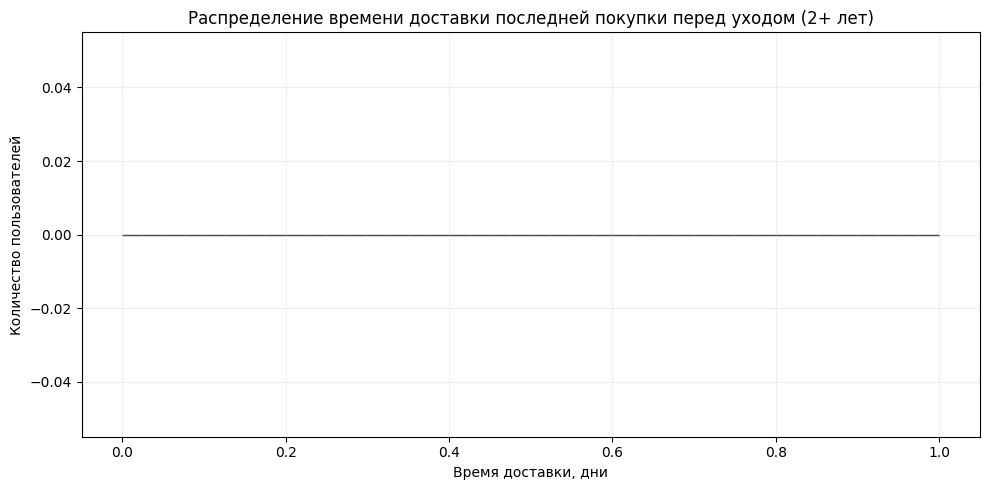

count    0.0
mean     NaN
std      NaN
min      NaN
50%      NaN
75%      NaN
90%      NaN
95%      NaN
max      NaN
Name: delivery_days, dtype: float64


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "data.csv"
INACTIVE_DAYS = 365 * 2  # 2+ years

def parse_dt(s):
    s = s.astype(str).str.strip().replace({
        "": np.nan, " ": np.nan, "null": np.nan, "none": np.nan,
        "nan": np.nan, "nat": np.nan, "na": np.nan
    })
    return pd.to_datetime(s, utc=True, errors="coerce")

# 1) Загружаем нужные поля
df = pd.read_csv(CSV_PATH, usecols=["user_id", "order_id", "created_at", "delivered_at"])

# 2) Парсим даты
df["created_at"] = parse_dt(df["created_at"])
df["delivered_at"] = parse_dt(df["delivered_at"])

# 3) База заказов (1 order_id = 1 строка)
orders = (
    df.dropna(subset=["user_id", "order_id", "created_at"])
      .sort_values(["user_id", "order_id", "created_at"])
      .drop_duplicates(subset=["order_id"], keep="first")
      .copy()
)

# 4) Время доставки
orders["delivery_days"] = (orders["delivered_at"] - orders["created_at"]).dt.total_seconds() / 86400
orders.loc[(orders["delivery_days"] < 0) | (orders["delivery_days"] > 120), "delivery_days"] = np.nan

# 5) Последняя покупка каждого пользователя
last_order = (
    orders.sort_values(["user_id", "created_at"])
          .groupby("user_id", as_index=False)
          .tail(1)
          .copy()
)

# 6) Уход = нет активности 2+ лет
obs_end = orders["created_at"].max()
last_order["days_since_last"] = (obs_end - last_order["created_at"]).dt.days
last_order["churn_2y"] = (last_order["days_since_last"] >= INACTIVE_DAYS).astype(int)

lost = last_order[(last_order["churn_2y"] == 1) & (last_order["delivery_days"].notna())].copy()

print(f"Всего пользователей: {last_order['user_id'].nunique():,}")
print(f"Ушедших (2+ лет): {last_order['churn_2y'].sum():,}")
print(f"С валидным delivery_days последней покупки: {len(lost):,}")

# 7) Распределение времени доставки последней покупки перед уходом
plt.figure(figsize=(10, 5))
plt.hist(lost["delivery_days"], bins=40, edgecolor="black", alpha=0.8)
plt.title("Распределение времени доставки последней покупки перед уходом (2+ лет)")
plt.xlabel("Время доставки, дни")
plt.ylabel("Количество пользователей")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# (опционально) сводные метрики
print(lost["delivery_days"].describe(percentiles=[0.5, 0.75, 0.9, 0.95]))


Ушедших пользователей: 22,965
Ушедших с хотя бы одной доставленной покупкой: 0


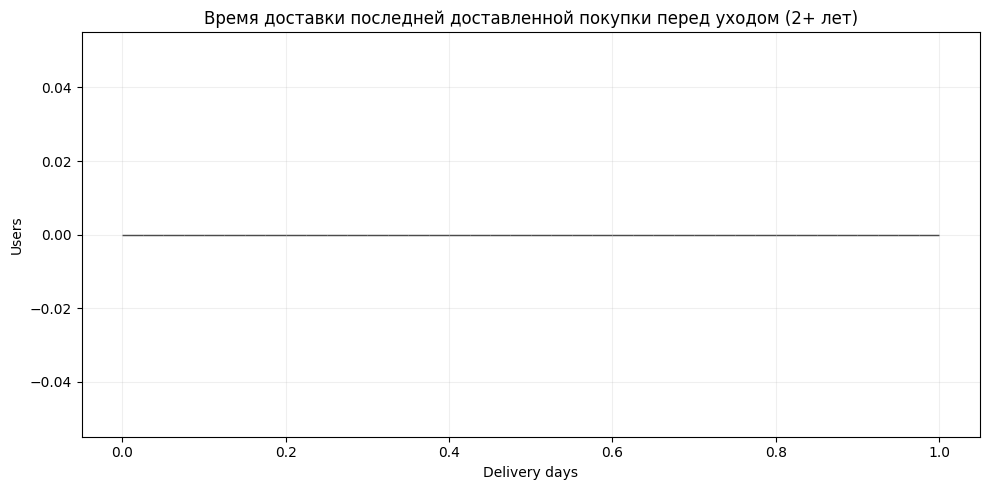

count    0.0
mean     NaN
std      NaN
min      NaN
50%      NaN
75%      NaN
90%      NaN
95%      NaN
max      NaN
Name: delivery_days, dtype: float64


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "data.csv"
INACTIVE_DAYS = 365 * 2  # 2+ years

def parse_mixed_dt(s):
    s = s.astype(str).str.strip().replace({
        "": np.nan, " ": np.nan, "null": np.nan, "none": np.nan,
        "nan": np.nan, "nat": np.nan, "na": np.nan
    })
    dt = pd.to_datetime(s, utc=True, errors="coerce")

    # fallback для epoch-форматов
    bad = dt.isna() & s.notna()
    if bad.any():
        num = pd.to_numeric(s[bad], errors="coerce").dropna()
        if len(num):
            best = None
            best_score = -1
            for unit in ["s", "ms", "us", "ns"]:
                cand = pd.to_datetime(num, unit=unit, utc=True, errors="coerce")
                score = ((cand.dt.year >= 2000) & (cand.dt.year <= 2035)).sum()
                if score > best_score:
                    best_score = score
                    best = cand
            if best is not None:
                dt.loc[best.index] = best
    return dt

df = pd.read_csv(CSV_PATH, usecols=["user_id", "order_id", "created_at", "delivered_at"])

df["created_at"] = parse_mixed_dt(df["created_at"])
df["delivered_at"] = parse_mixed_dt(df["delivered_at"])

orders = (
    df.dropna(subset=["user_id", "order_id", "created_at"])
      .sort_values(["user_id", "order_id", "created_at"])
      .drop_duplicates(subset=["order_id"], keep="first")
      .copy()
)

# churn 2y по последней активности (created_at)
obs_end = orders["created_at"].max()
last_any = orders.sort_values(["user_id", "created_at"]).groupby("user_id", as_index=False).tail(1).copy()
last_any["days_since_last"] = (obs_end - last_any["created_at"]).dt.days
last_any["churn_2y"] = (last_any["days_since_last"] >= INACTIVE_DAYS).astype(int)

lost_users = set(last_any.loc[last_any["churn_2y"] == 1, "user_id"])

# только доставленные заказы
deliv = orders.dropna(subset=["delivered_at"]).copy()
deliv["delivery_days"] = (deliv["delivered_at"] - deliv["created_at"]).dt.total_seconds() / 86400
deliv = deliv[(deliv["delivery_days"] >= 0) & (deliv["delivery_days"] <= 120)].copy()

# последняя ДОСТАВЛЕННАЯ покупка ушедшего пользователя
last_deliv_lost = (
    deliv[deliv["user_id"].isin(lost_users)]
    .sort_values(["user_id", "created_at"])
    .groupby("user_id", as_index=False)
    .tail(1)
    .copy()
)

print(f"Ушедших пользователей: {len(lost_users):,}")
print(f"Ушедших с хотя бы одной доставленной покупкой: {last_deliv_lost['user_id'].nunique():,}")

plt.figure(figsize=(10, 5))
plt.hist(last_deliv_lost["delivery_days"], bins=40, edgecolor="black", alpha=0.8)
plt.title("Время доставки последней доставленной покупки перед уходом (2+ лет)")
plt.xlabel("Delivery days")
plt.ylabel("Users")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(last_deliv_lost["delivery_days"].describe(percentiles=[0.5, 0.75, 0.9, 0.95]))


In [23]:
import pandas as pd
import numpy as np

CSV_PATH = "data.csv"
INACTIVE_DAYS = 365 * 2

def parse_dt(s):
    s = s.astype(str).str.strip().replace({
        "": np.nan, " ": np.nan, "null": np.nan, "none": np.nan,
        "nan": np.nan, "nat": np.nan, "na": np.nan
    })
    return pd.to_datetime(s, utc=True, errors="coerce")

df = pd.read_csv(CSV_PATH, usecols=["user_id","order_id","created_at","delivered_at","shipped_at","status"])
for c in ["created_at","delivered_at","shipped_at"]:
    df[c] = parse_dt(df[c])

orders = (
    df.dropna(subset=["user_id","order_id","created_at"])
      .sort_values(["user_id","order_id","created_at"])
      .drop_duplicates("order_id", keep="first")
      .copy()
)

obs_end = orders["created_at"].max()
last_any = orders.sort_values(["user_id","created_at"]).groupby("user_id", as_index=False).tail(1).copy()
last_any["days_since_last"] = (obs_end - last_any["created_at"]).dt.days
last_any["churn_2y"] = (last_any["days_since_last"] >= INACTIVE_DAYS).astype(int)

lost_ids = set(last_any.loc[last_any["churn_2y"] == 1, "user_id"])

lost_orders = orders[orders["user_id"].isin(lost_ids)].copy()
print("Ушедших пользователей:", len(lost_ids))
print("Ушедшие: доля заказов с delivered_at:", lost_orders["delivered_at"].notna().mean())
print("Ушедшие: доля заказов с shipped_at:", lost_orders["shipped_at"].notna().mean())
print("Ушедшие: статусы\n", lost_orders["status"].astype(str).str.lower().value_counts().head(10))


Ушедших пользователей: 22965
Ушедшие: доля заказов с delivered_at: 0.0
Ушедшие: доля заказов с shipped_at: 0.6523786772233977
Ушедшие: статусы
 status
shipped       8851
complete      7392
processing    5799
cancelled     4387
returned      2873
Name: count, dtype: int64


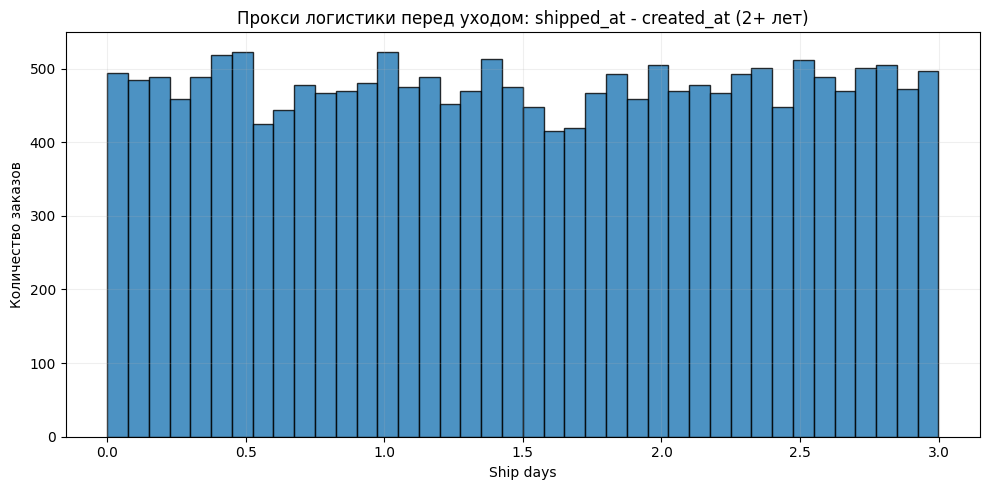

In [24]:
import matplotlib.pyplot as plt

lost_orders["ship_days"] = (lost_orders["shipped_at"] - lost_orders["created_at"]).dt.total_seconds()/86400
lost_ship = lost_orders[(lost_orders["ship_days"] >= 0) & (lost_orders["ship_days"] <= 120)].copy()

plt.figure(figsize=(10,5))
plt.hist(lost_ship["ship_days"], bins=40, edgecolor="black", alpha=0.8)
plt.title("Прокси логистики перед уходом: shipped_at - created_at (2+ лет)")
plt.xlabel("Ship days")
plt.ylabel("Количество заказов")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
